A. Importing and Loading Dataset

In [42]:
import os
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [43]:


current_dir = os.getcwd()

path = os.path.join(current_dir, "..", "data", "raw")
all_files = glob.glob(os.path.join(path,"*.csv"))

print("Loading Data")

df = pd.concat((pd.read_csv(f, low_memory=False) for f in all_files), ignore_index=True)
    
df.columns = df.columns.str.strip()

list_df = []

for f in all_files:
    temp_df = pd.read_csv(f, low_memory=False)
    # cleaning from nan data
    temp_df.columns = temp_df.columns.str.strip()
    
    
    list_df.append(temp_df)

df = pd.concat(list_df, ignore_index=True)


Loading Data


In [44]:
#showing the first 20 rows 
df.head(20)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
5,54871,1022,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
6,54925,4,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
7,54925,42,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
8,9282,4,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
9,55153,4,2,0,37,0,31,6,18.500000,17.677670,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [45]:
# Checking the Dimensions of the Dataset
df.shape

(2830743, 79)

In [46]:
# Checking the info of the data:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow IAT Mi

In [47]:
# Checking the datatypes of the columns 
df.dtypes

Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                              str
Length: 79, dtype: object

In [48]:
# Counting all of the data types 
print(df.dtypes.value_counts())

int64      54
float64    24
str         1
Name: count, dtype: int64


B.Identify the number of missing values

In [49]:
NanN_data = df.isnull().sum().sort_values(ascending=False)
print(NanN_data)

Flow Bytes/s                   1358
Flow Duration                     0
Destination Port                  0
Total Backward Packets            0
Total Length of Fwd Packets       0
                               ... 
Idle Mean                         0
Idle Std                          0
Idle Max                          0
Idle Min                          0
Label                             0
Length: 79, dtype: int64


C. Remove and Fill the missing values

In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace = True)


In [51]:
df["Flow Bytes/s"] = df["Flow Bytes/s"].fillna(df["Flow Bytes/s"].mean())

Nans_data = df.isnull().sum().sort_values(ascending=False)
print(Nans_data)
df.head(20)

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
5,54871,1022,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
6,54925,4,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
7,54925,42,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
8,9282,4,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
9,55153,4,2,0,37,0,31,6,18.500000,17.677670,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


Summary of the numeric stats and adding median

In [52]:
numeric_stats = df.describe().T
numeric_stats['median'] = df.median(numeric_only=True)
print(numeric_stats)

                                 count          mean           std   min  \
Destination Port             2827876.0  8.061534e+03  1.827432e+04   0.0   
Flow Duration                2827876.0  1.480065e+07  3.366750e+07 -13.0   
Total Fwd Packets            2827876.0  9.368972e+00  7.500527e+02   1.0   
Total Backward Packets       2827876.0  1.040396e+01  9.978937e+02   0.0   
Total Length of Fwd Packets  2827876.0  5.498522e+02  9.998639e+03   0.0   
...                                ...           ...           ...   ...   
Active Min                   2827876.0  5.835492e+04  5.773818e+05   0.0   
Idle Mean                    2827876.0  8.324468e+06  2.364057e+07   0.0   
Idle Std                     2827876.0  5.043548e+05  4.605289e+06   0.0   
Idle Max                     2827876.0  8.704568e+06  2.437766e+07   0.0   
Idle Min                     2827876.0  7.928061e+06  2.337390e+07   0.0   

                               25%      50%         75%          max   median  
Destina

D. Data Transfomration

We have a string data type in Label

Encode categorical variables


In [53]:
Label =df["Label"].to_list()

In [54]:
Label = np.array(Label)
Label.shape = (-1,1)

In [55]:
Label.shape

(2827876, 1)

In [56]:
le = LabelEncoder()
label = le.fit_transform(df["Label"])

In [67]:
print(df["Label"].unique())

[ 0  2 10  1  9 12 14 13  7 11  6  5  4  3  8]


In [58]:
df.drop("Label",axis=1,inplace=True)
df["Label"] = label

In [59]:
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,53,32215,4,2,112,152,28,28,28.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2830739,53,324,2,2,84,362,42,42,42.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2830740,58030,82,2,1,31,6,31,0,15.5,21.92031,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
2830741,53,1048635,6,2,192,256,32,32,32.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


D. Duplicates

Το σύνολο δεδομένων CIC-IDS-2017 περιλαμβάνει χαρακτηριστικά δικτυακής κίνησης που εξήχθησαν με το εργαλείο CICFlowMeter. Οι στήλες χωρίζονται σε κατηγορίες όπως:

    Ταυτότητα Ροής: Destination Port, Protocol.

    Χρονικά Χαρακτηριστικά: Flow Duration, Flow IAT (Inter-Arrival Time).

    Μεγέθη Πακέτων: Total Fwd/Bwd Packets, Packet Length.

    Στατιστικά Ταχύτητας: Flow Bytes/s, Flow Packets/s.

In [60]:
print(df.duplicated().sum())

307078


Remove duplicates

In [61]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


E. Visualization of outliers and Statistical Summary

Label Analysis

In [ ]:
label_counts = df['Label'].value_counts()
label_probs = df['Label'].value_counts(normalize=True) * 100

print("Distribution:")
print(label_counts)

Κατανομή Κλάσεων:
Label
0     2095057
4      172846
2      128014
10      90694
3       10286
7        5931
6        5385
5        5228
11       3219
1        1948
12       1470
14        652
9          36
13         21
8          11
Name: count, dtype: int64


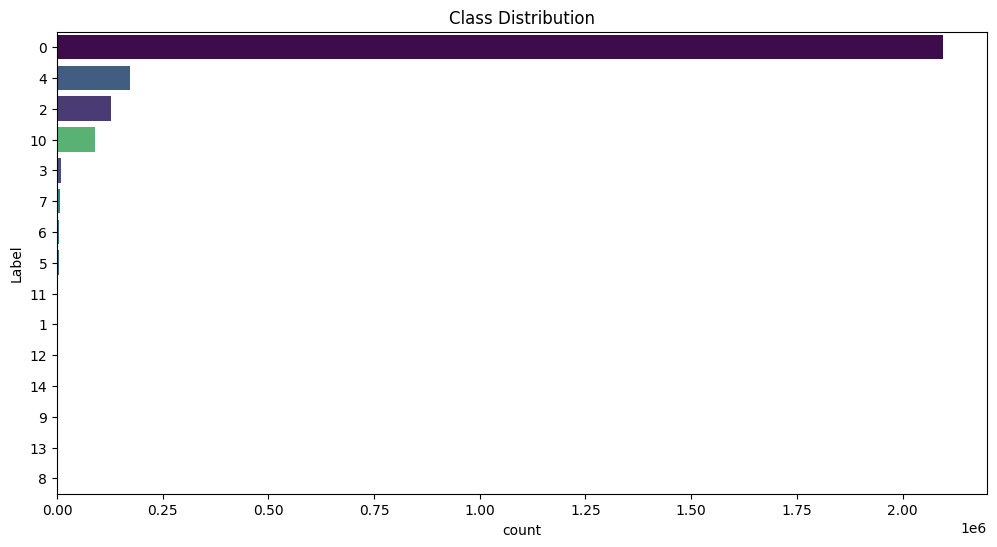

In [62]:
plt.figure(figsize=(12,6))

order = df['Label'].value_counts().index
sns.countplot(data=df, y='Label', order=order,hue="Label", palette='viridis',legend=False)
plt.title('Class Distribution')
plt.show()



Statistical for summarization

In [71]:
stats = df.describe().T
print(stats)

                                 count          mean           std  \
Destination Port             2520798.0  8.690590e+03  1.901280e+04   
Flow Duration                2520798.0  1.659161e+07  3.523276e+07   
Total Fwd Packets            2520798.0  1.028174e+01  7.944201e+02   
Total Length of Fwd Packets  2520798.0  6.119477e+02  1.058827e+04   
Fwd Packet Length Max        2520798.0  2.312292e+02  7.563755e+02   
Fwd Packet Length Min        2520798.0  1.920349e+01  6.079834e+01   
Fwd Packet Length Mean       2520798.0  6.350497e+01  1.955526e+02   
Bwd Packet Length Max        2520798.0  9.749726e+02  2.038347e+03   
Bwd Packet Length Min        2520798.0  4.315945e+01  7.087972e+01   
Flow Bytes/s                 2520798.0  1.410707e+06  2.657084e+07   
Flow Packets/s               2520798.0  4.729188e+04  2.026366e+05   
Flow IAT Mean                2520798.0  1.446142e+06  4.683197e+06   
Flow IAT Std                 2520798.0  3.278153e+06  8.456754e+06   
Flow IAT Max        

Finding the outliers

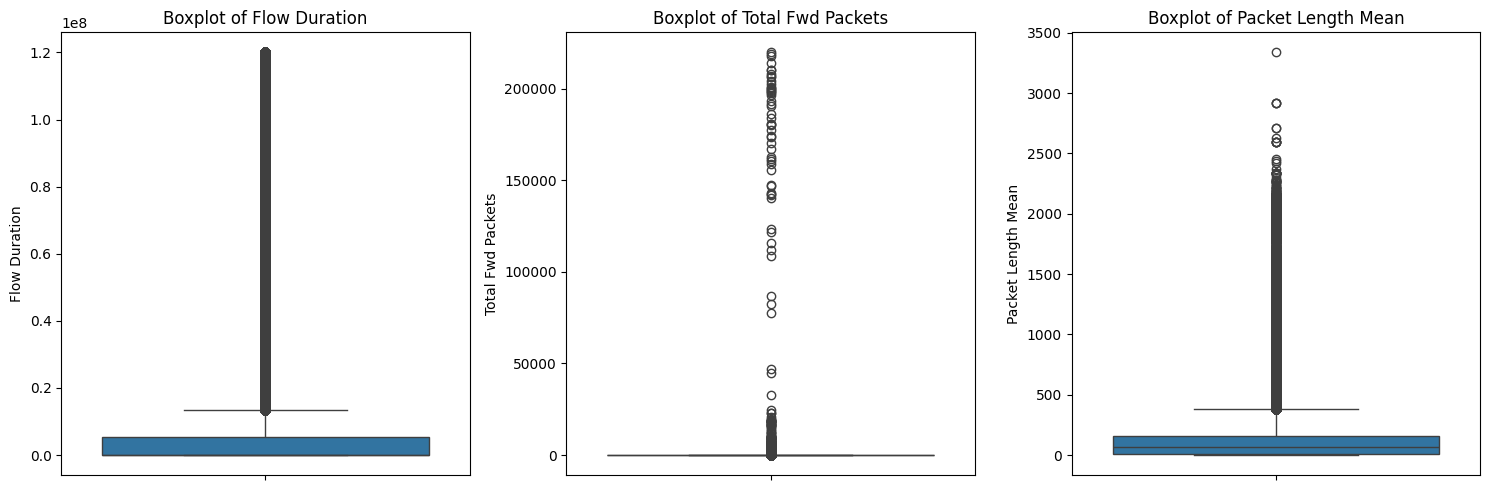

In [72]:
important_cols = ['Flow Duration', 'Total Fwd Packets', 'Packet Length Mean']

plt.figure(figsize=(15, 5))
for i, col in enumerate(important_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

Correlation Heatmap

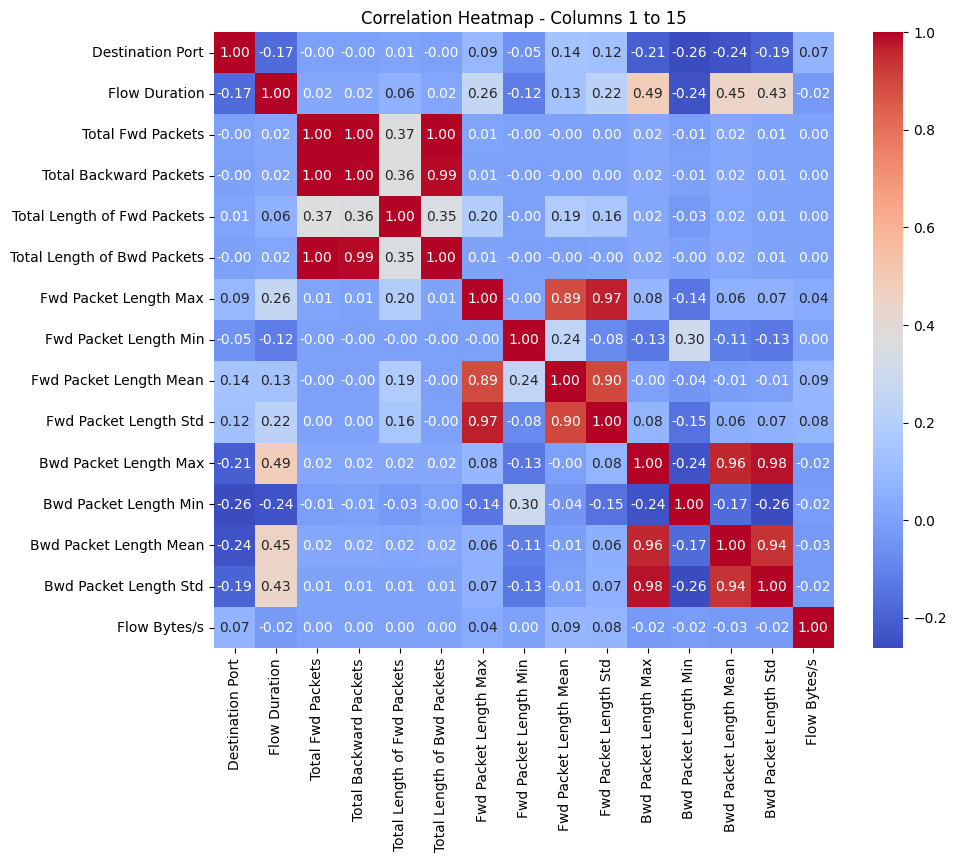

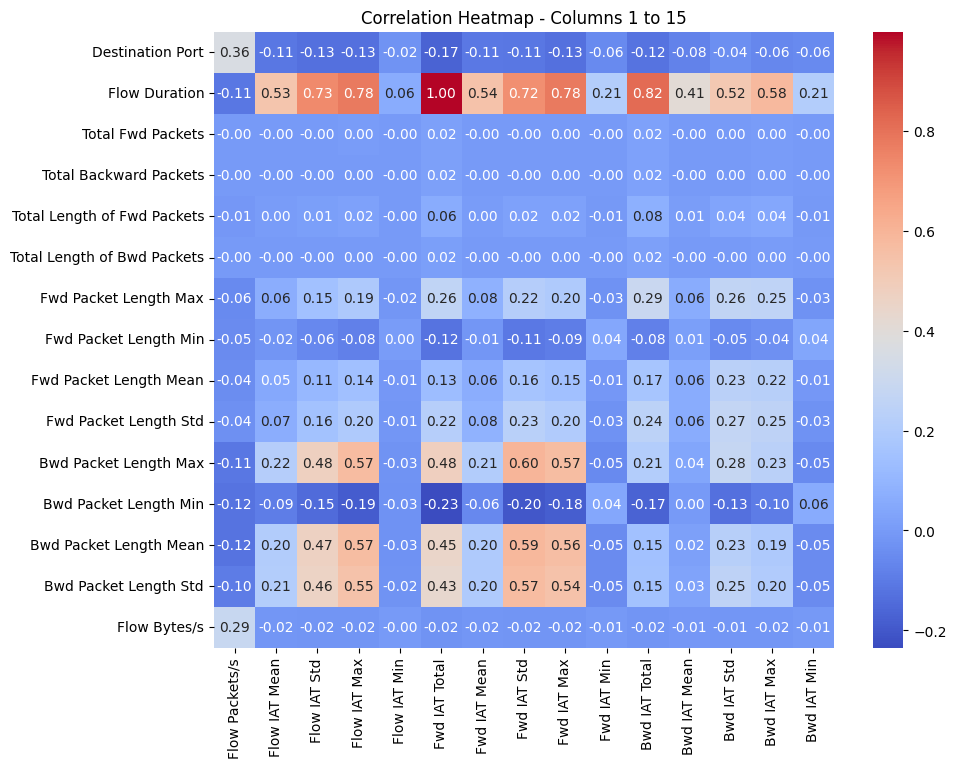

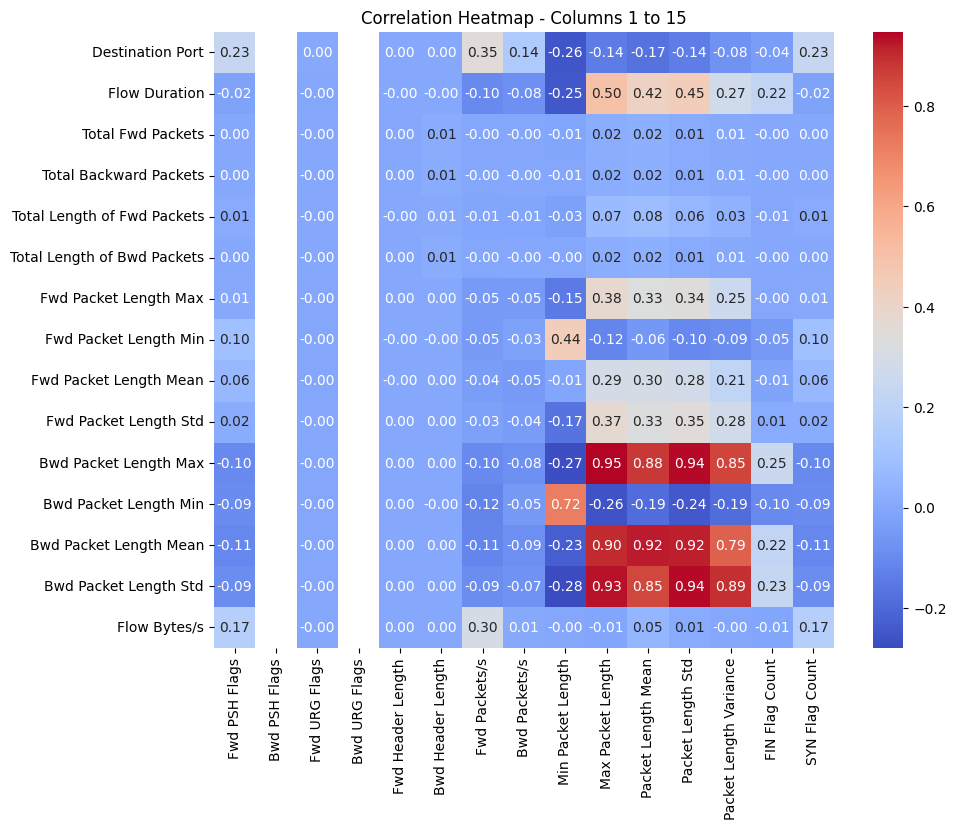

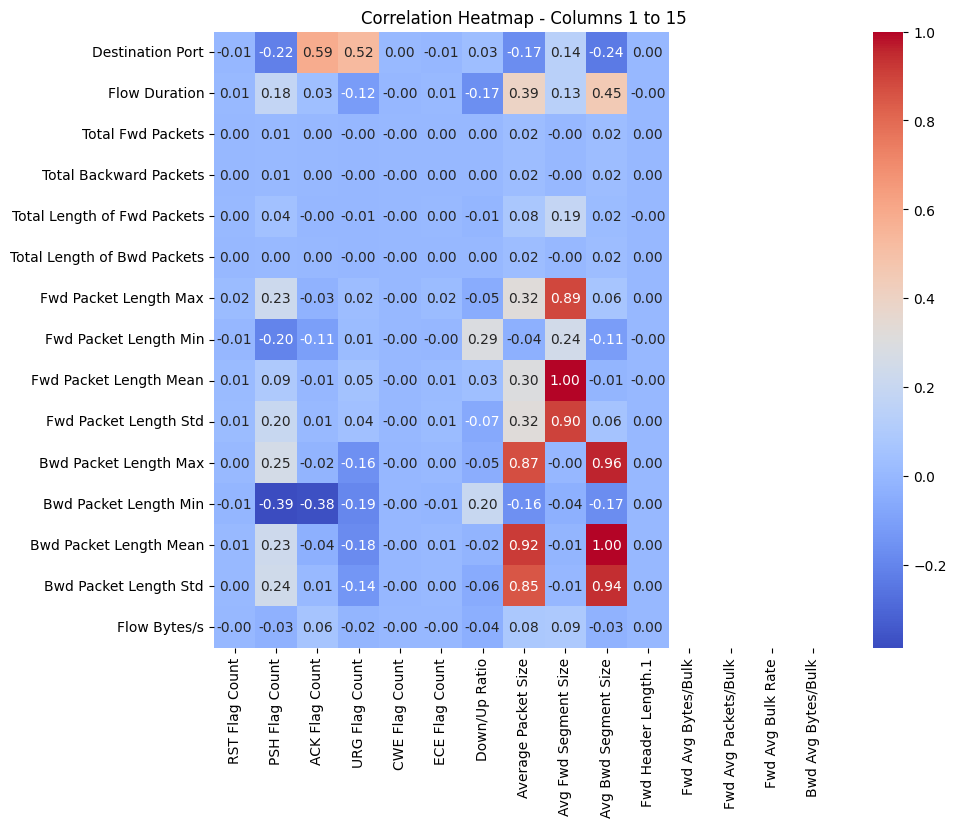

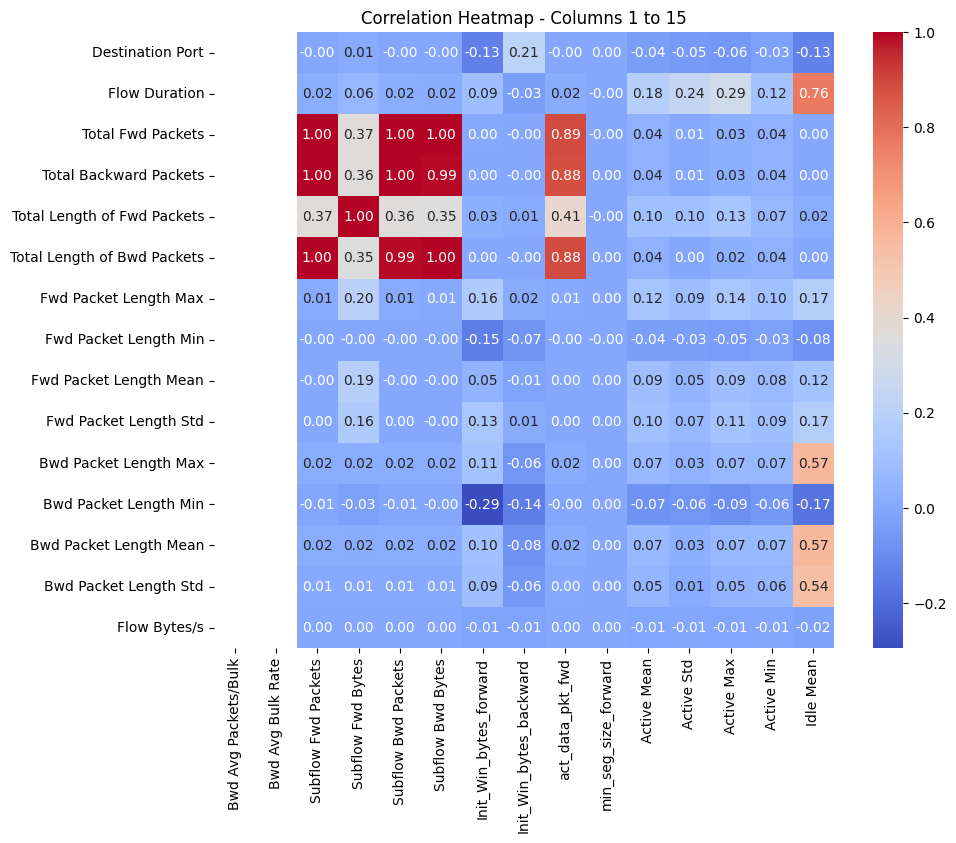

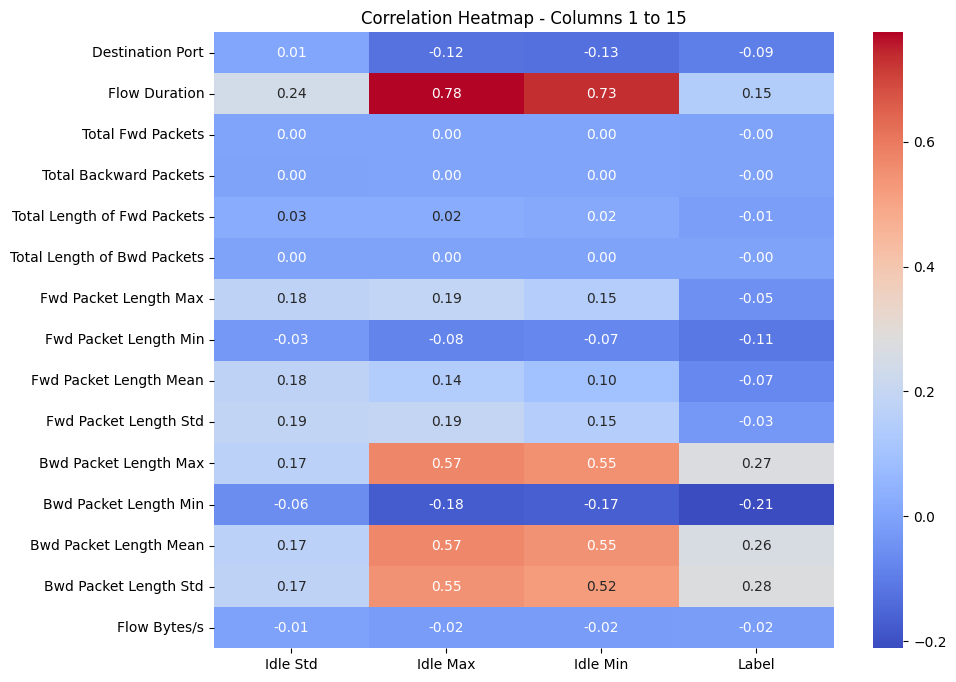

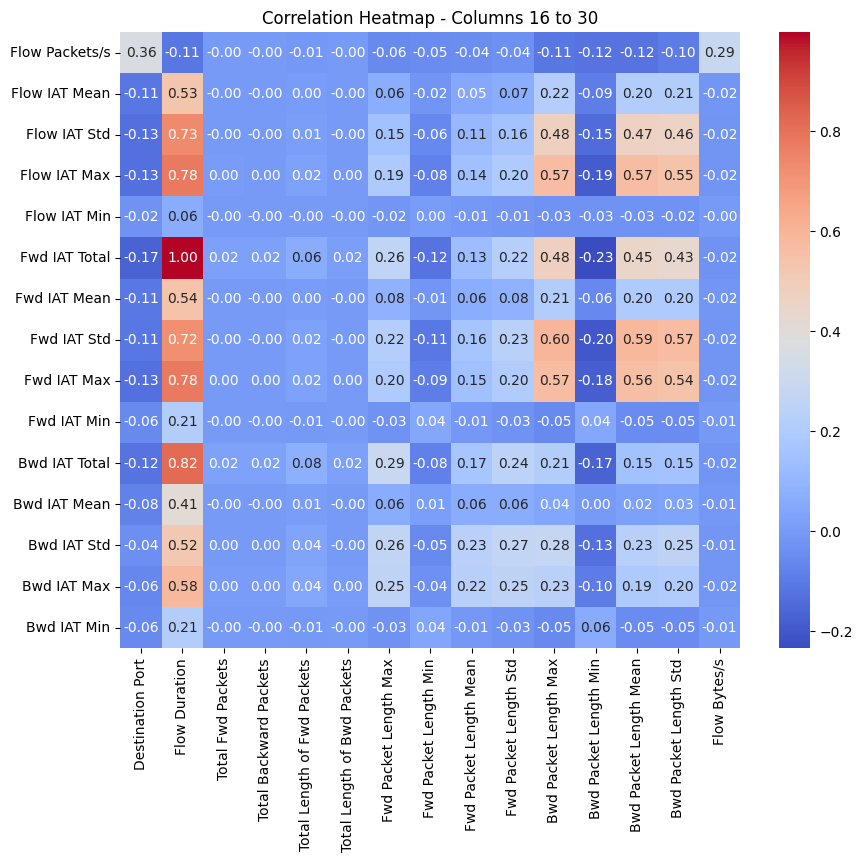

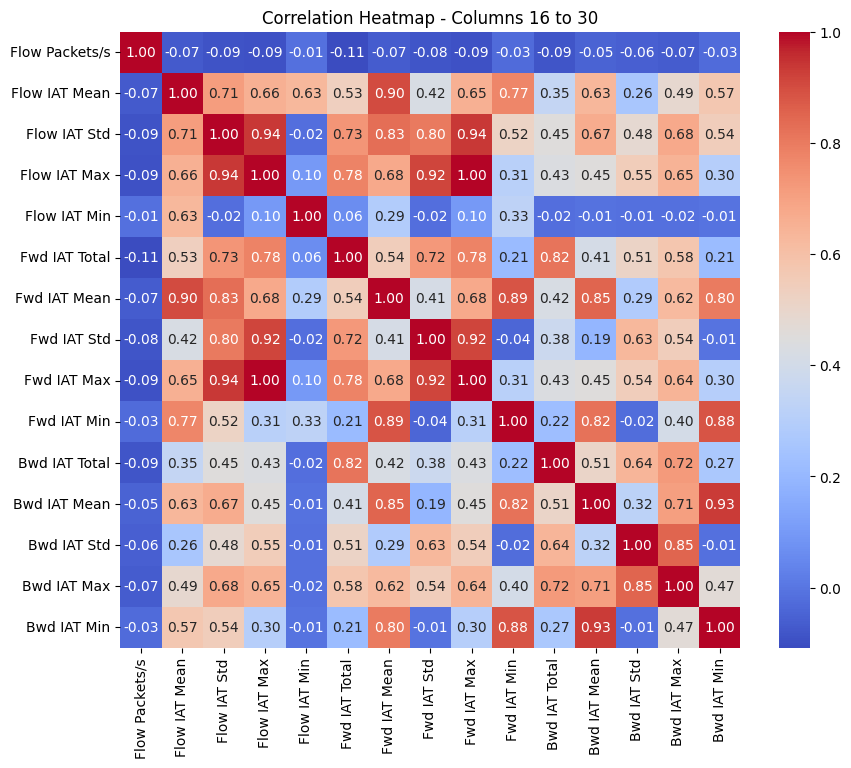

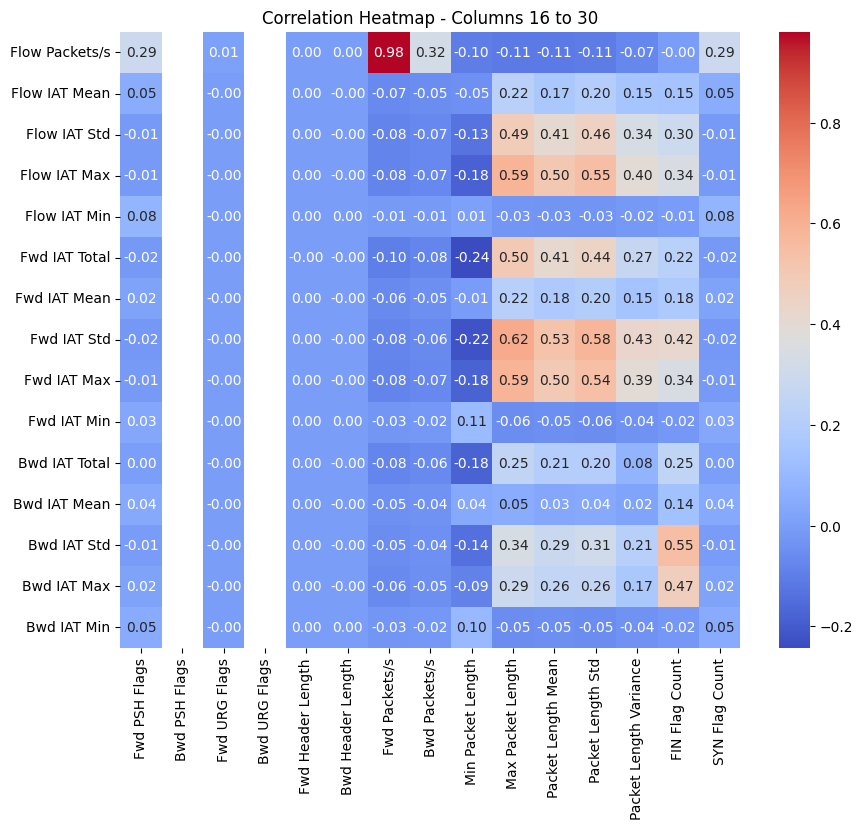

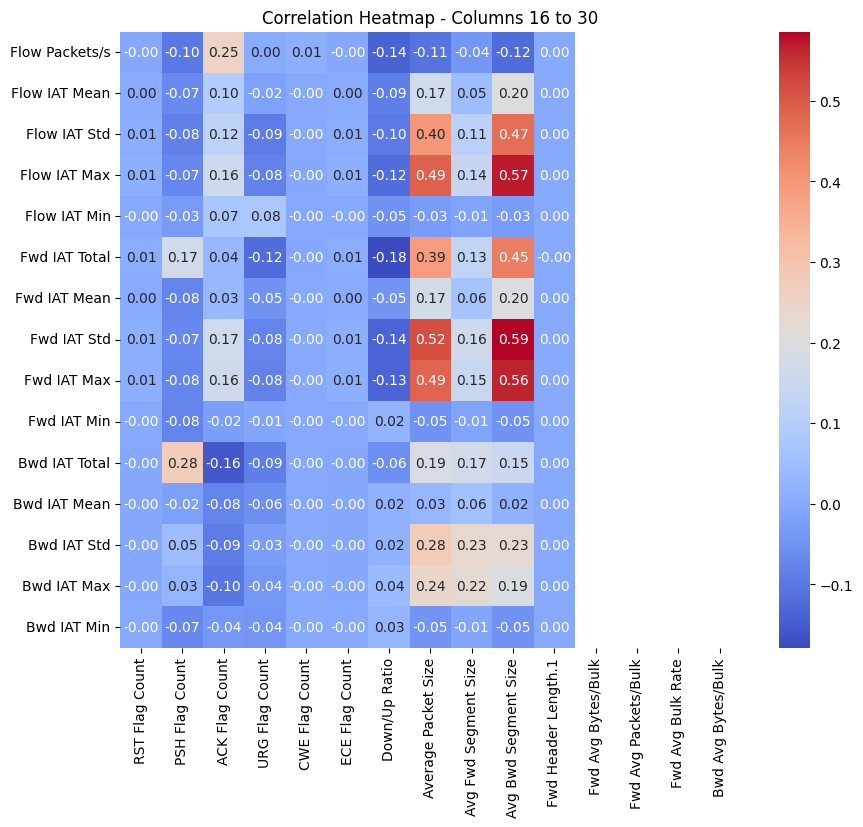

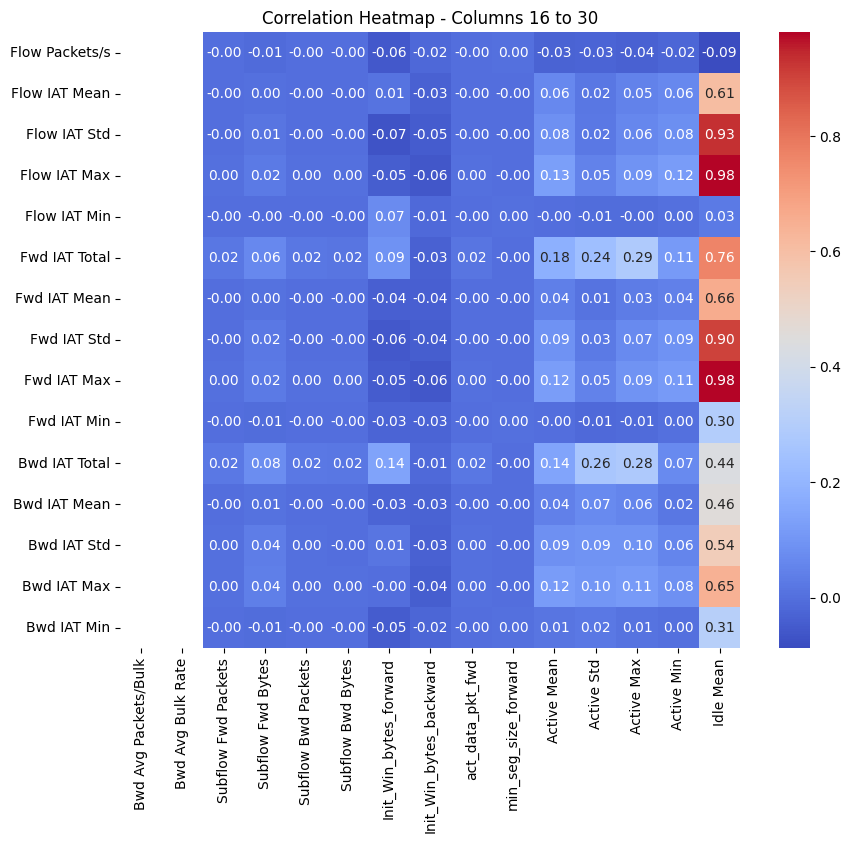

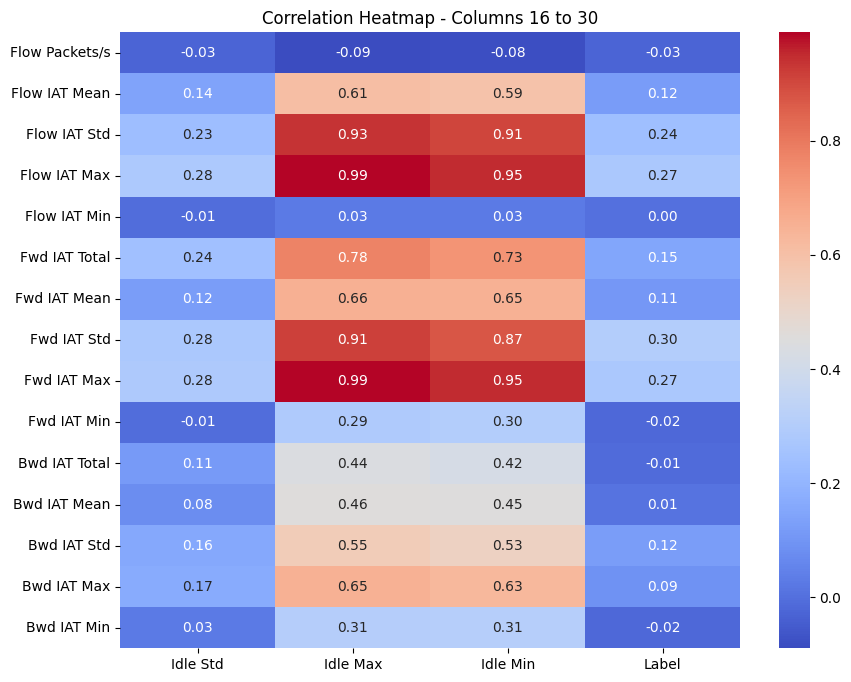

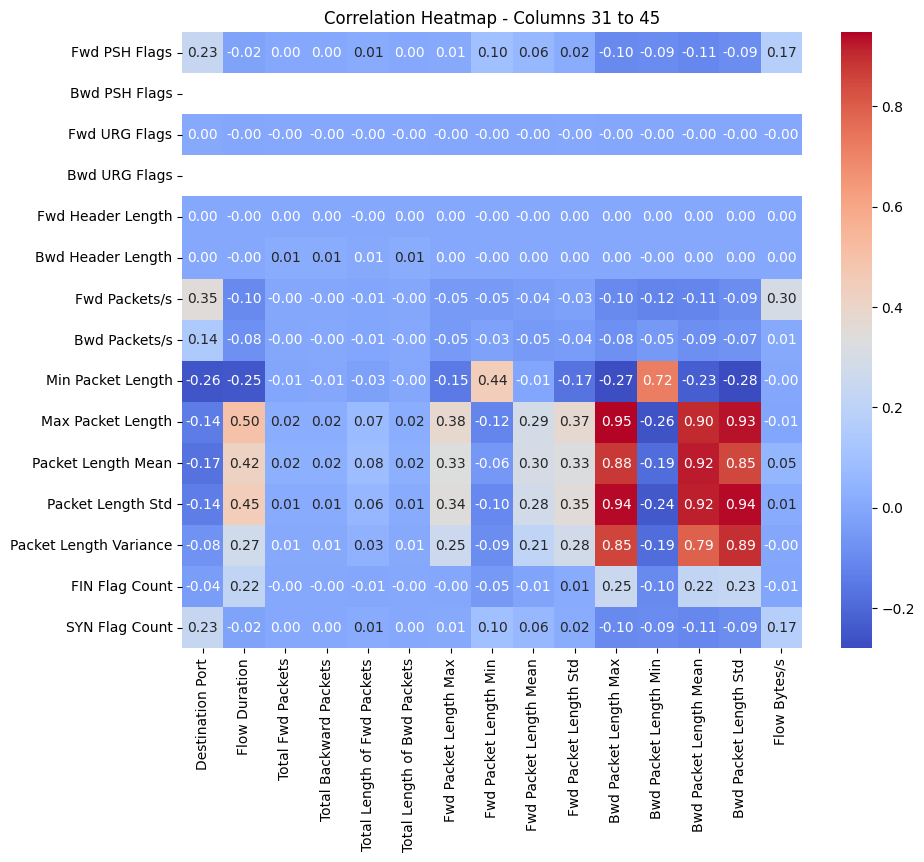

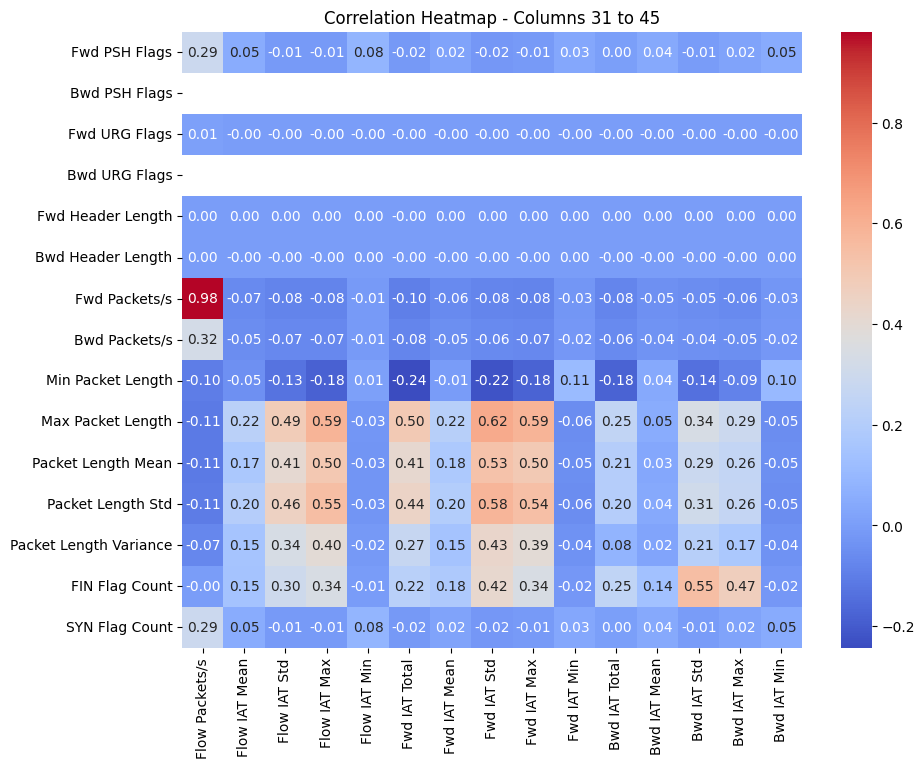

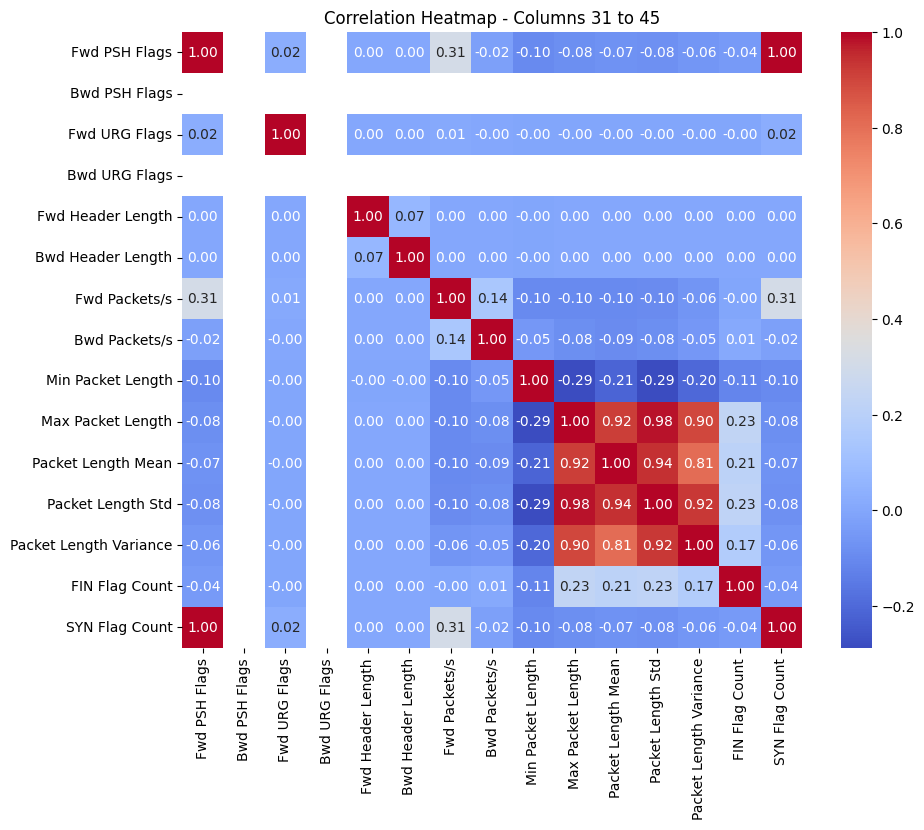

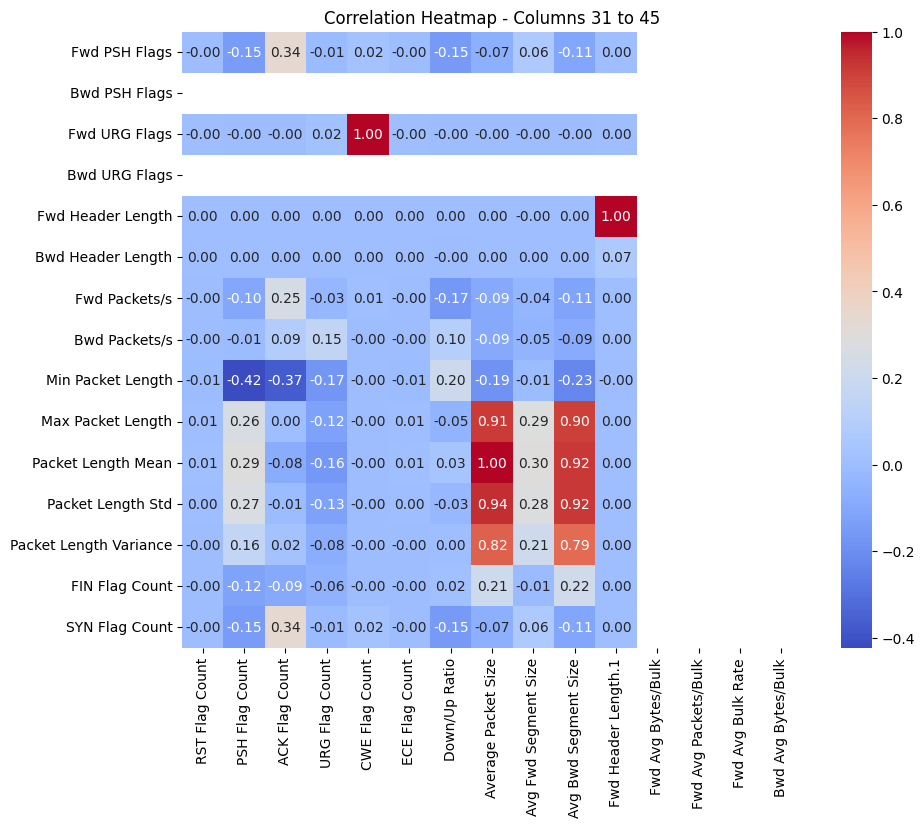

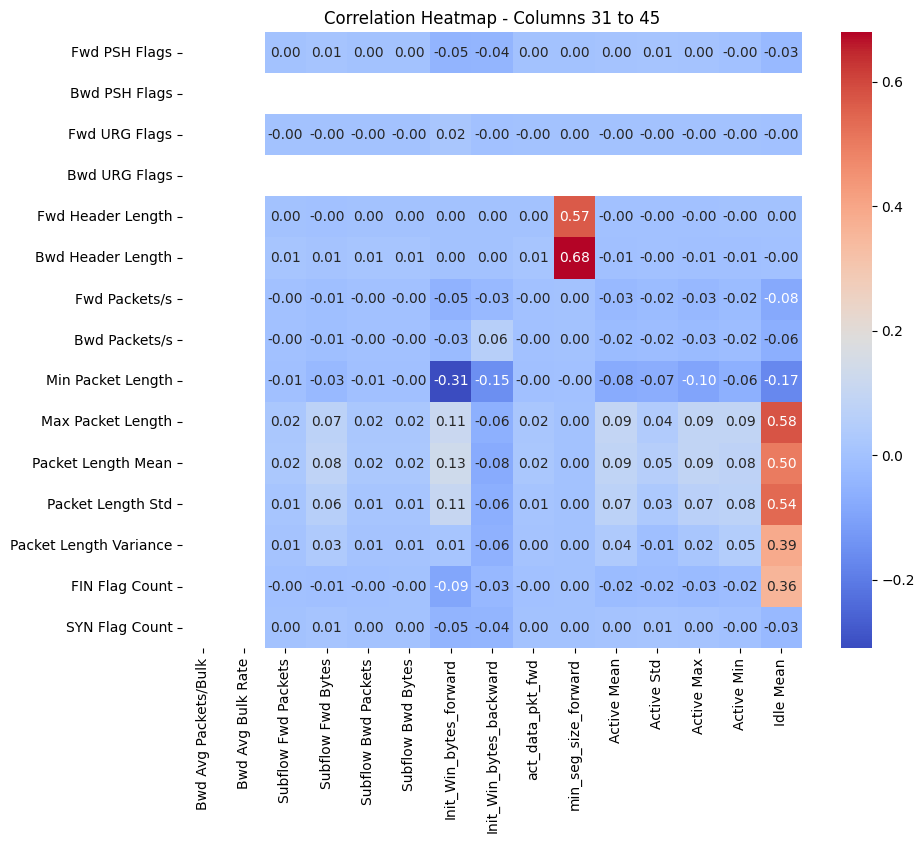

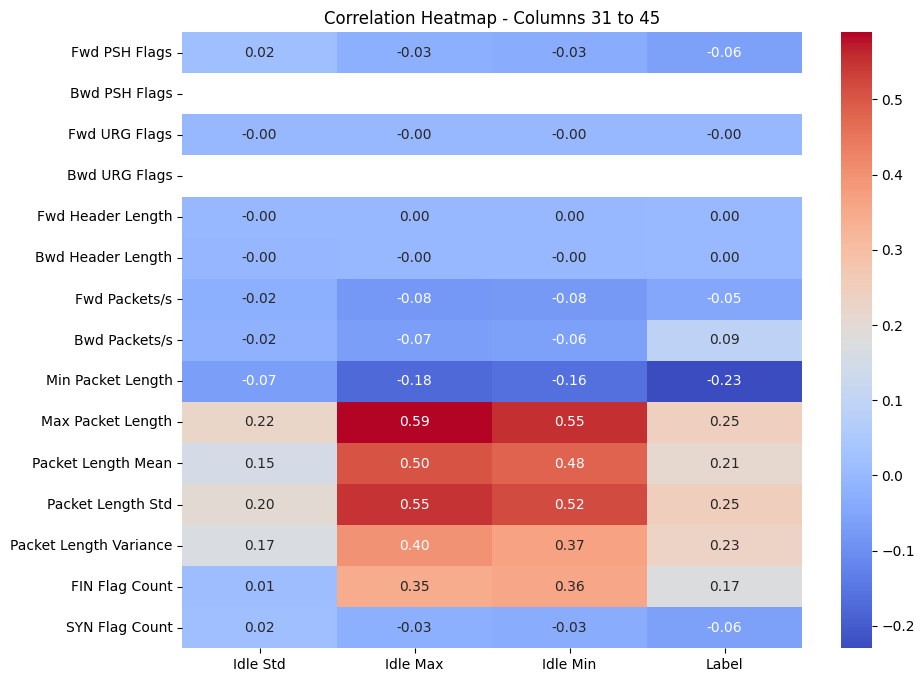

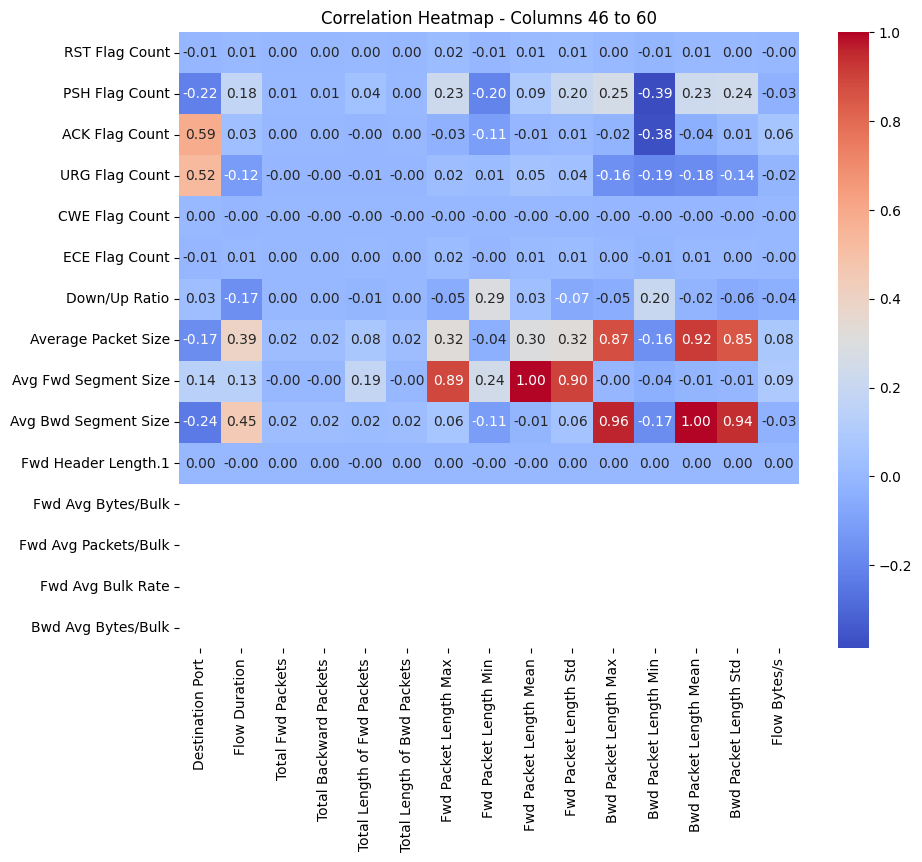

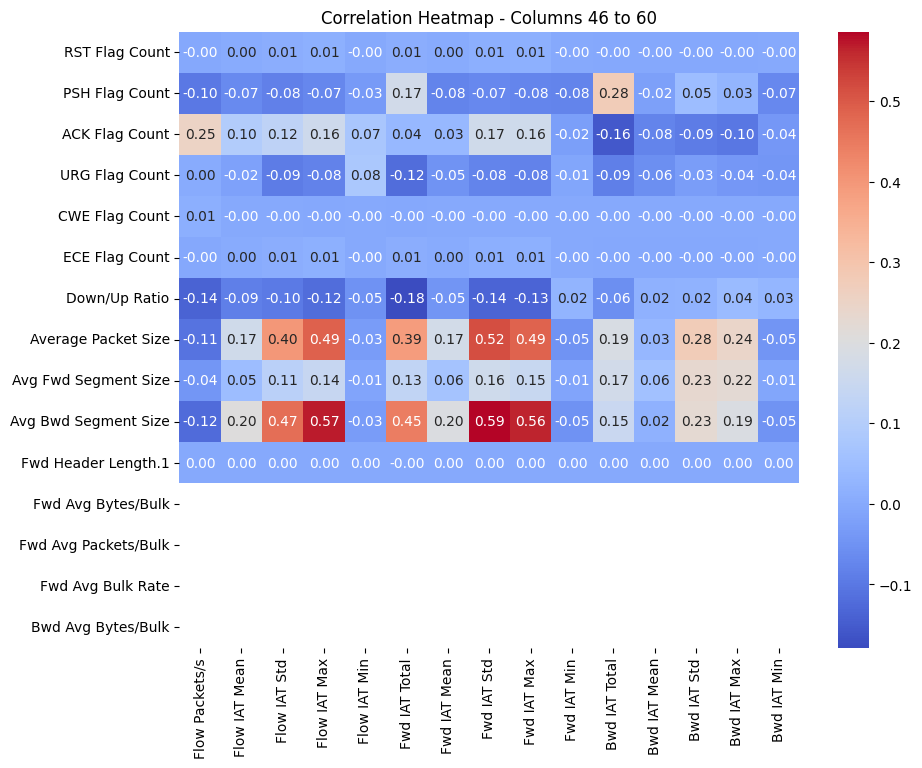

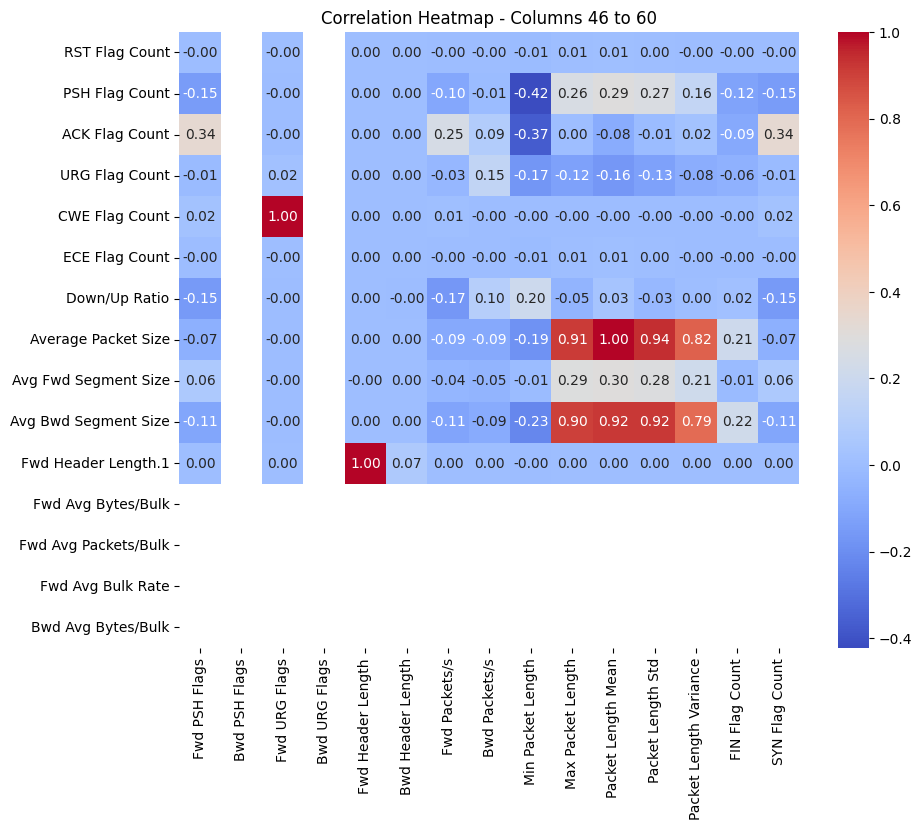

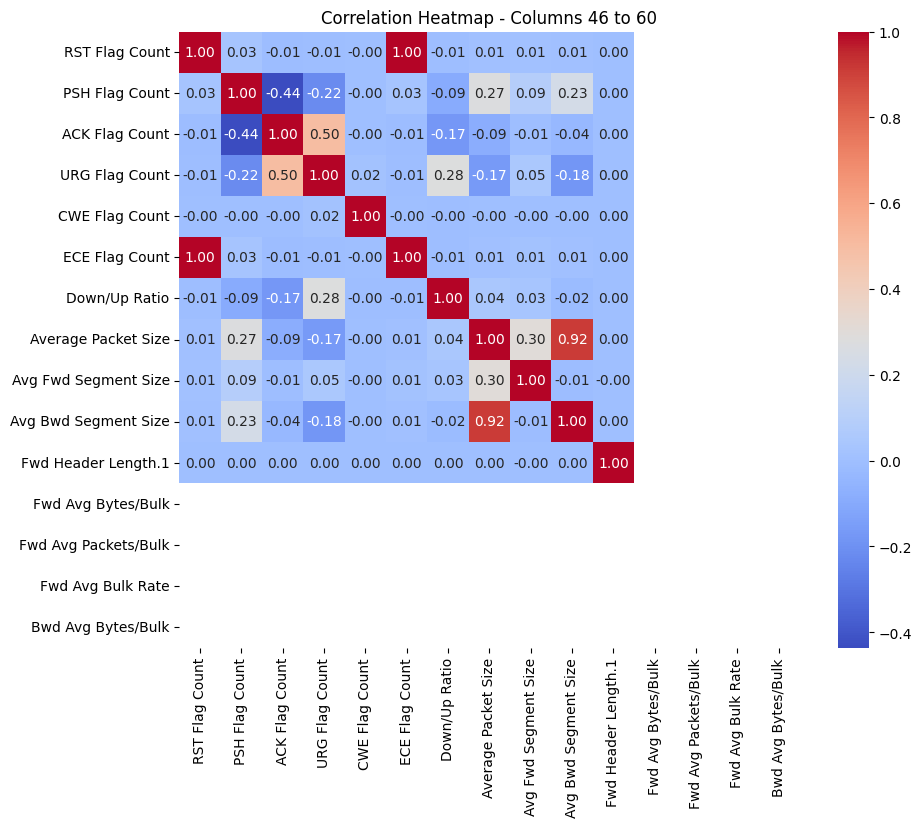

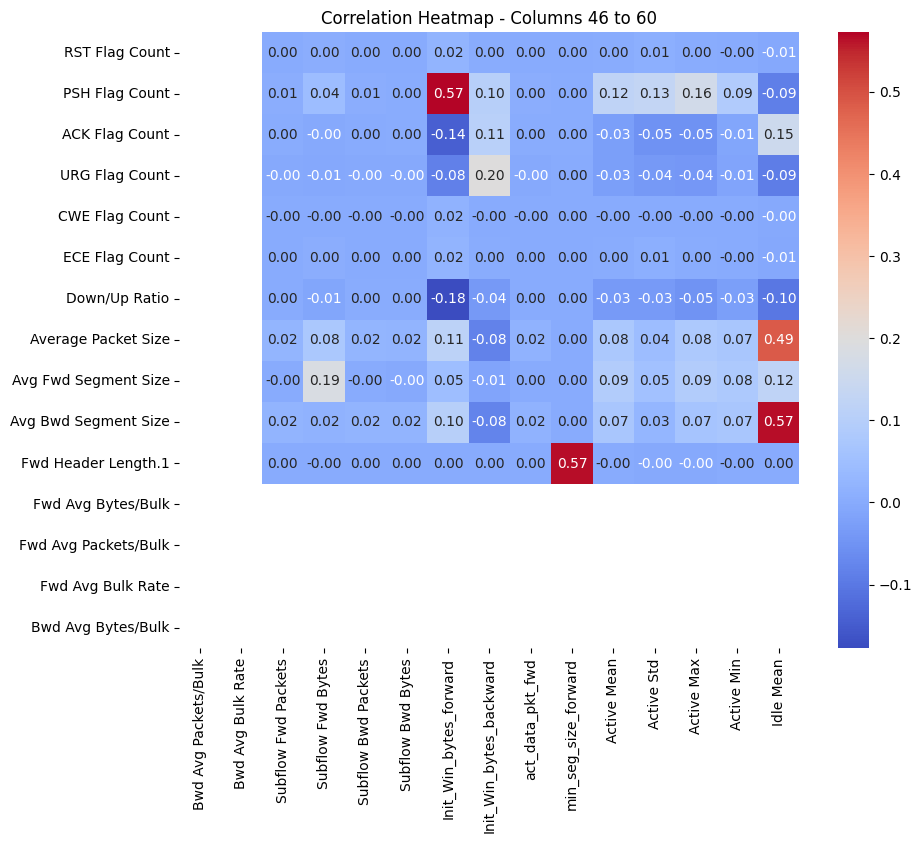

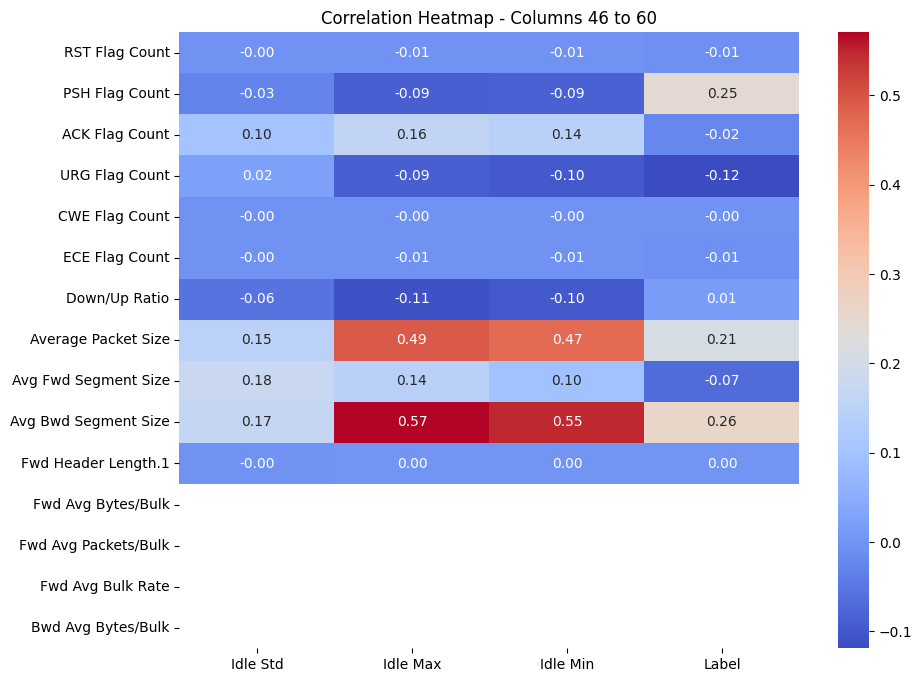

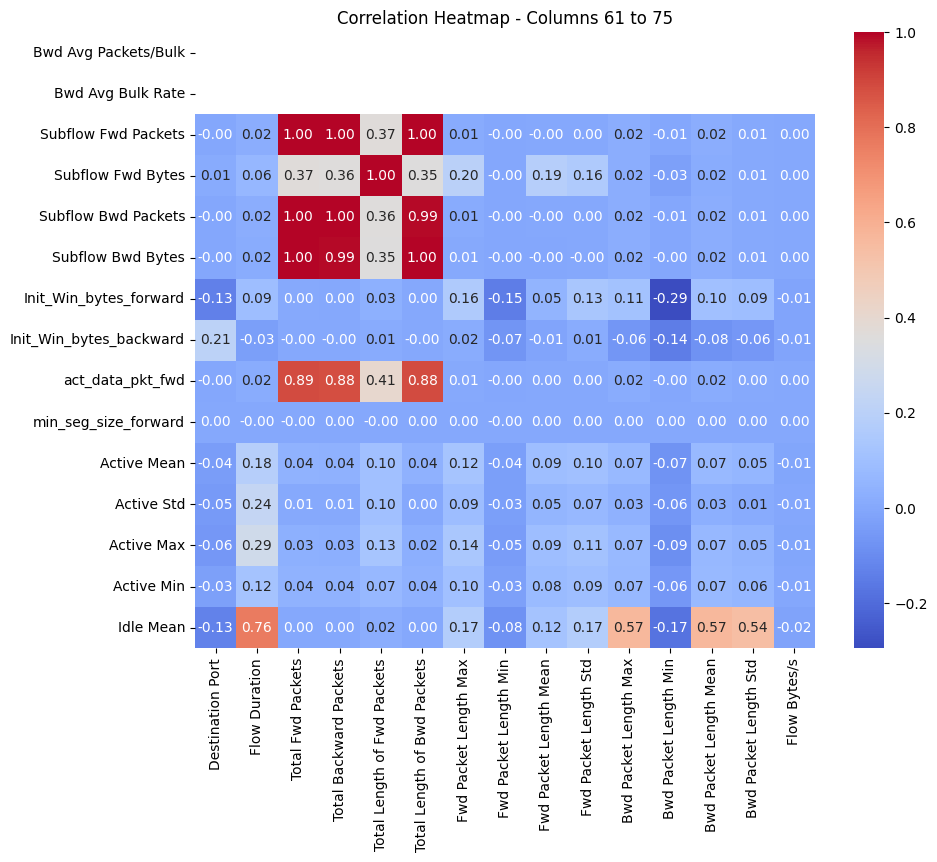

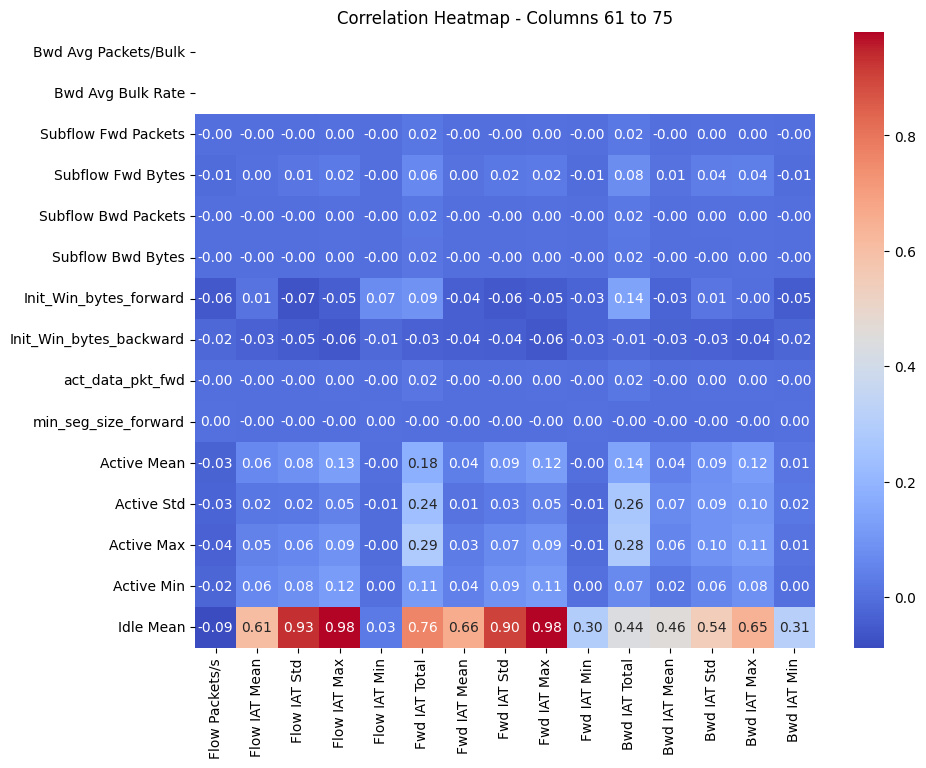

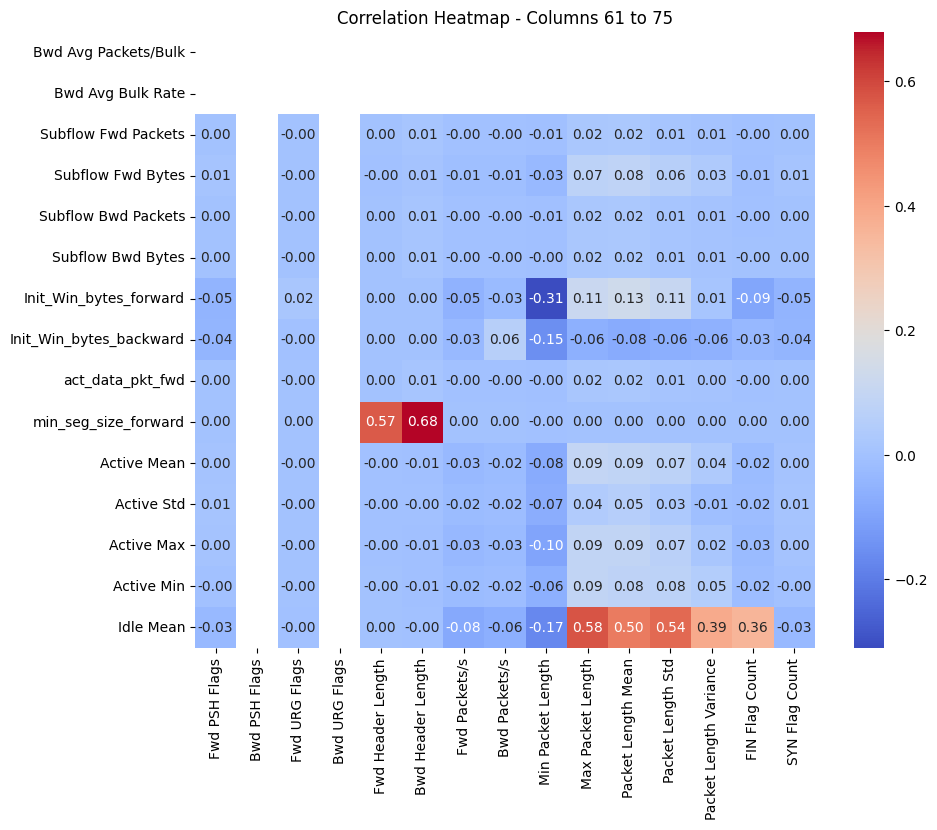

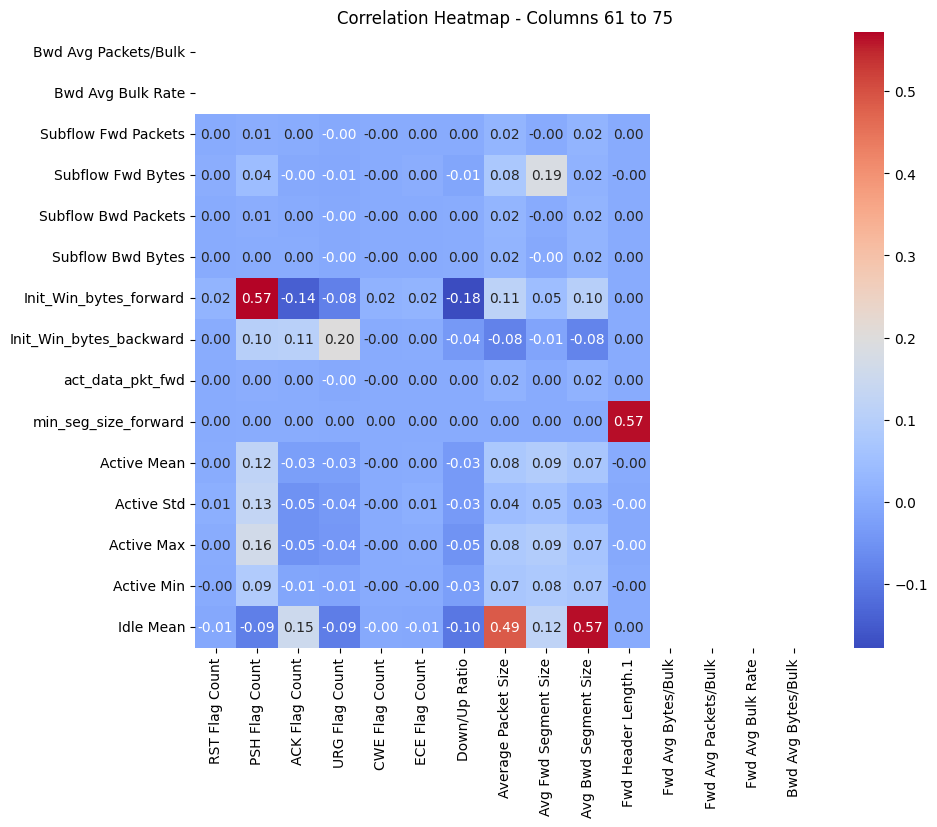

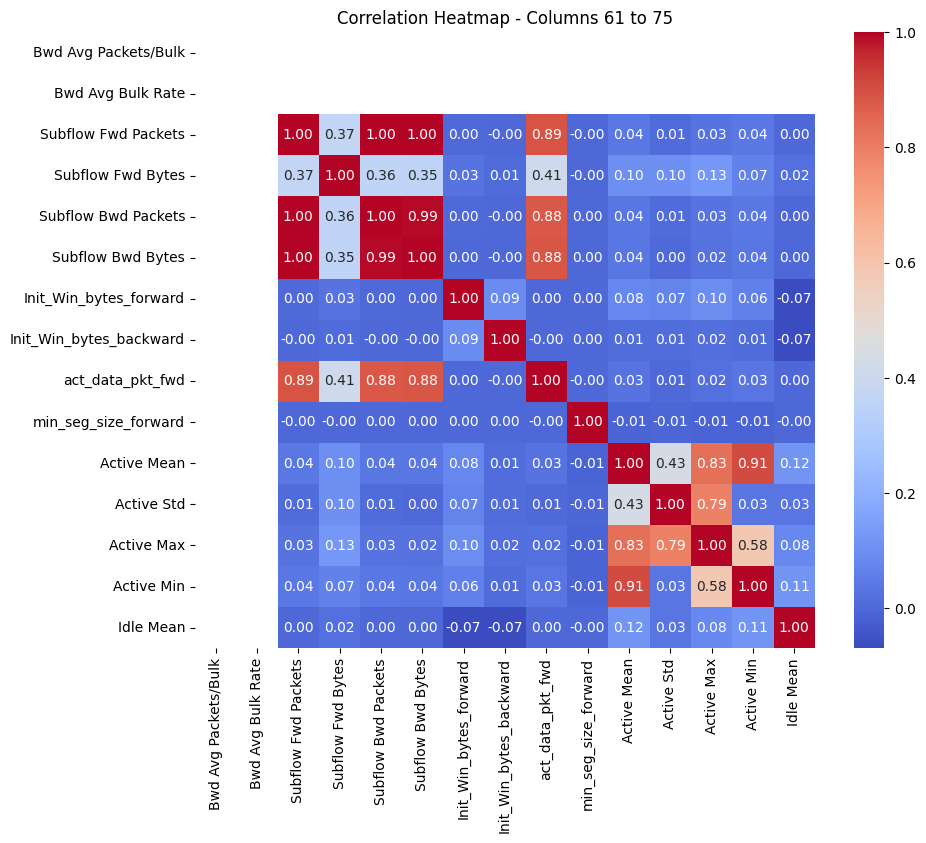

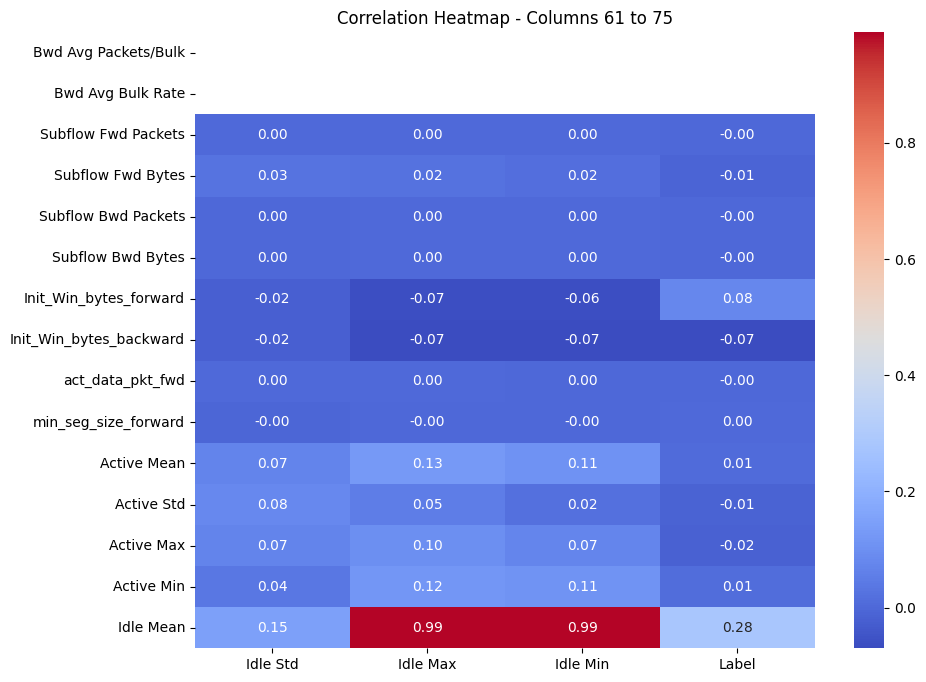

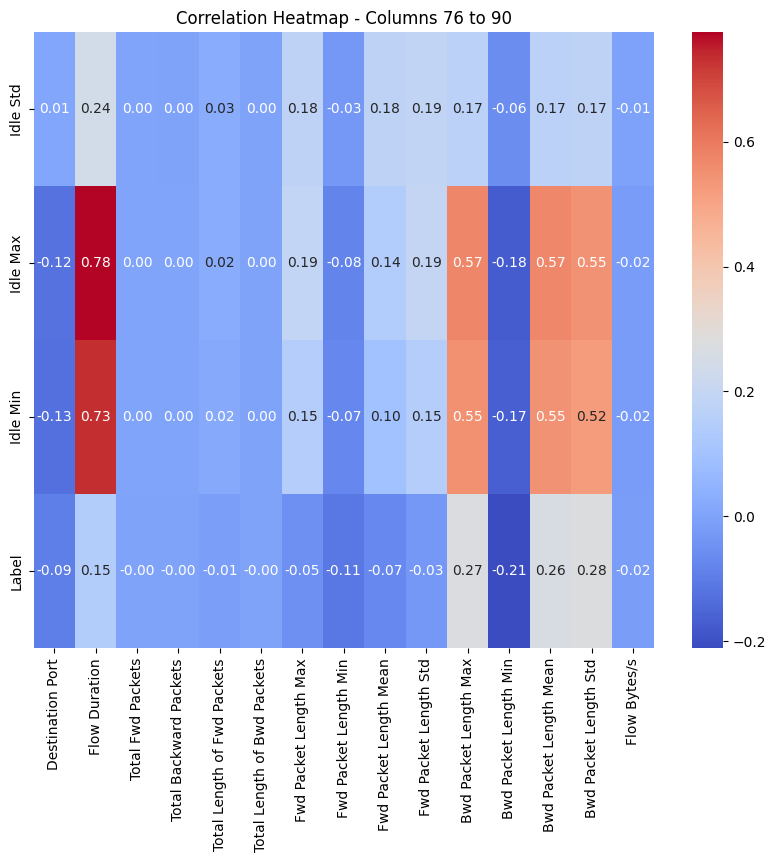

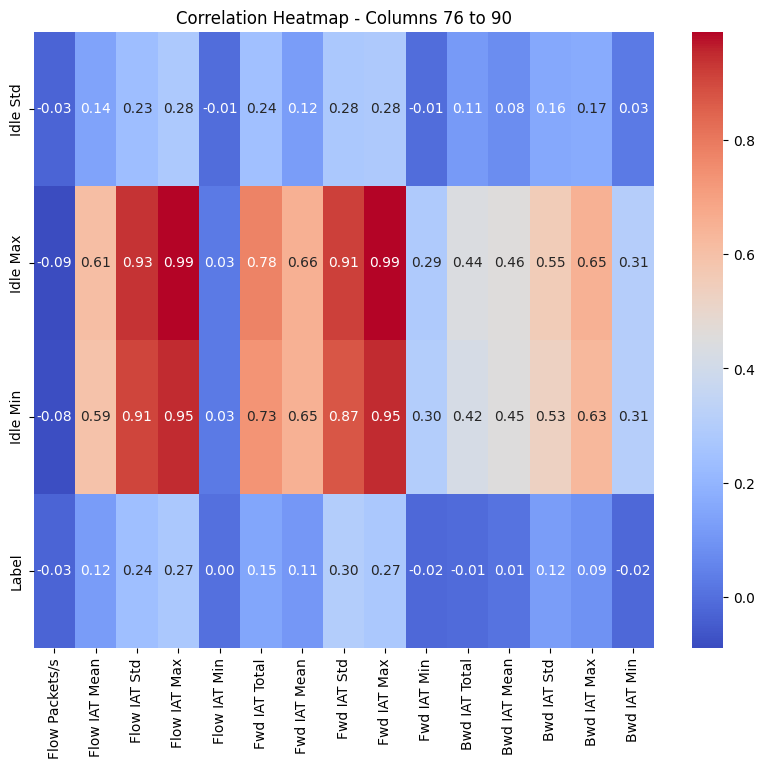

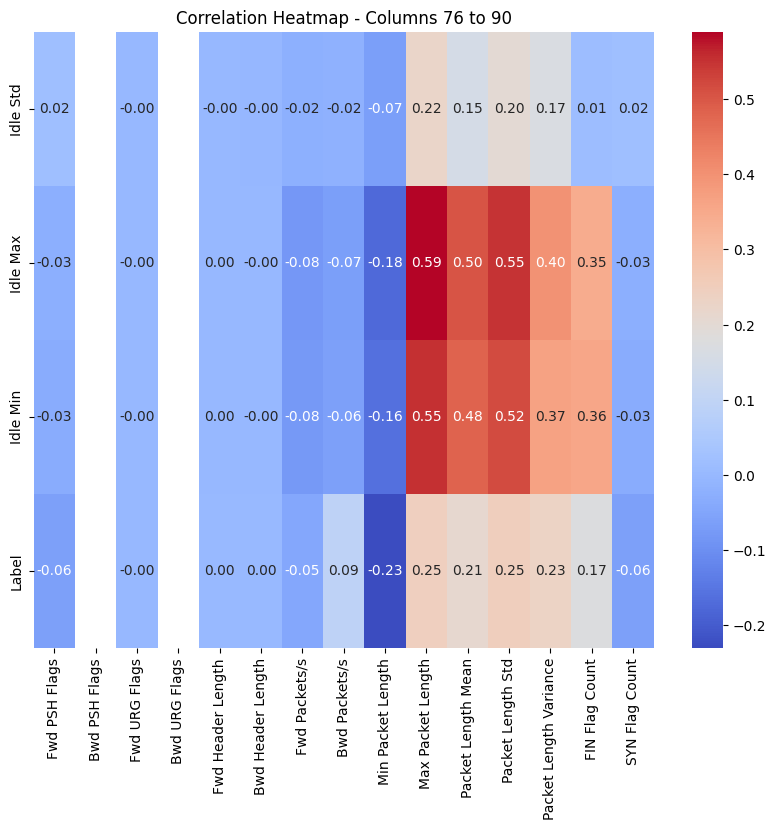

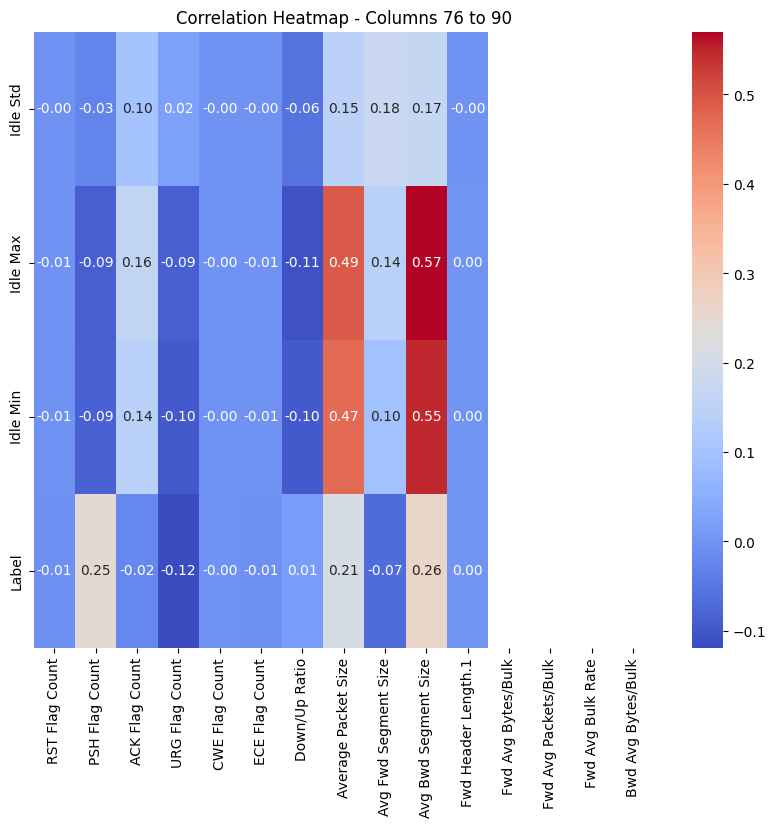

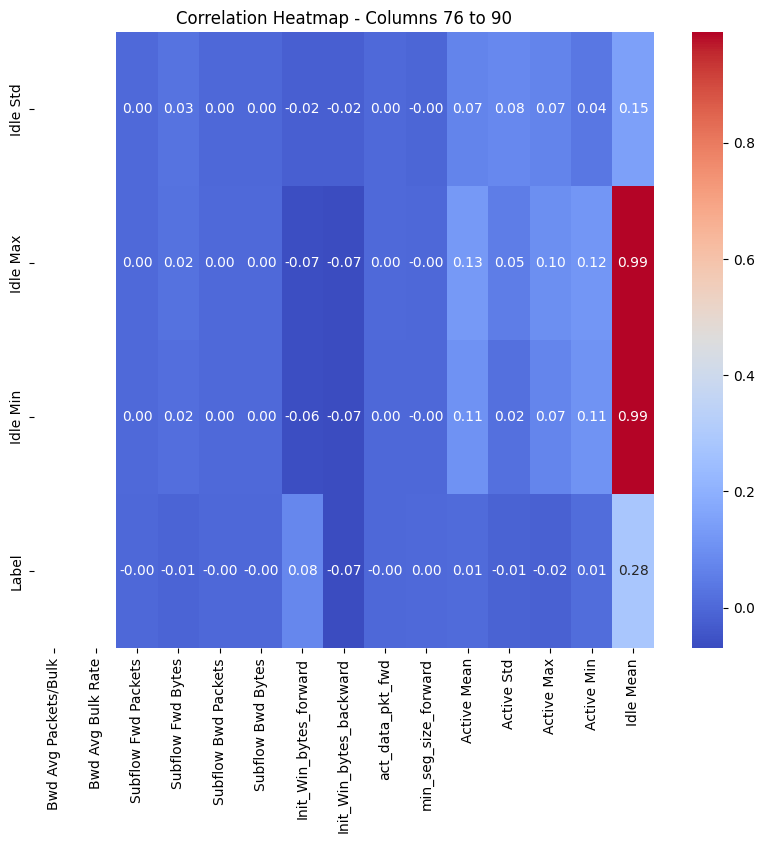

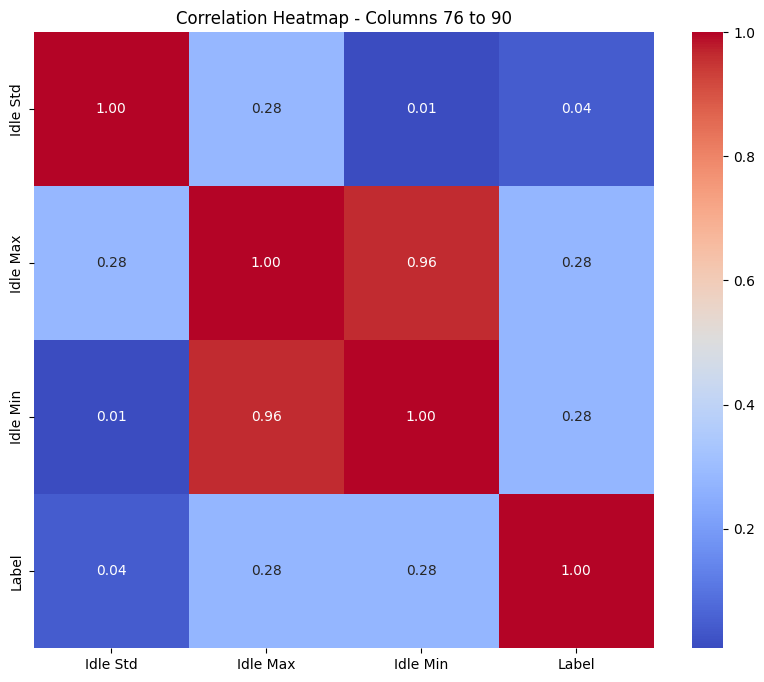

In [68]:
correlation_matrix = df.corr()
heatmap_segment_size = 15

num_columns = len(correlation_matrix.columns)
for i in range(0, num_columns, heatmap_segment_size):
    for j in range(0, num_columns, heatmap_segment_size):
        subset_corr_matrix = correlation_matrix.iloc[i:i+heatmap_segment_size, j:j+heatmap_segment_size]

        plt.figure(figsize=(10, 8))
        sns.heatmap(subset_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title("Correlation Heatmap - Columns {} to {}".format(i+1, i+heatmap_segment_size))
        plt.show()


Feature Selection

In [69]:
corr_matrix = df.corr()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

df.drop(columns=to_drop, inplace=True)
print(f"Removed {len(to_drop)}")

Removed 23
